<CENTER>
    <a href="http://opendata.atlas.cern" class="icons"><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/raw/master/images/ATLASOD.gif" style="width:40%"></a>
</CENTER>

# Measuring multijet production with ATLAS Open Data

Events with two or more jets are the LHC's most common interesting final state and a demanding test of QCD: each additional jet is a higher order in the perturbative expansion, so the rate at which jets multiply probes the theory where it is hardest to calculate. Multijets are also the dominant background
to most searches for new physics.

## The two levels

Everything here depends on one distinction, so it comes before any code.

|  | **Detector level** | **Particle level** |
|---|---|---|
| **Data** | what ATLAS recorded | *the measurement*  data corrected for detector effects |
| **Simulation** | after full GEANT4 detector simulation | generator output, before any detector |

Data and simulation-after-detector-simulation live at the **same level** and are directly comparable the paper selects events and jets using identical criteria in both. Simulation exists at *both* levels natively; it is never "corrected". The measurement is data brought from detector level to particle
level, using correction factors derived from simulation.

Every ratio in this notebook names the sample and the level on each side. A ratio whose two sides sit at different levels is not a comparison of anything.

## What we measure

* **differential cross sections** $d\sigma/dp_T$ for the four leading jets,
* the **inclusive jet multiplicity** $\sigma(N_\text{jet} \geq n)$,
* the **jet ratio** $\sigma_n/\sigma_{n-1}$, where most uncertainties cancel.

## Contents

[Getting the software](#setup) <br />
[Selection and analysis parameters](#config) <br />
[Samples](#samples) <br />
[Event weights](#weights) <br />
[Rapidity](#rapidity) <br />
[Jet and event selection](#selection) <br />
[Binning](#binning) <br />
[Filling histograms](#filling) <br />
[Migration matrices](#migration) <br />
[Processing the samples](#mainloop) <br />
[The correction chain](#correction) <br />
[Detector-level validation](#validation) <br />
[Closure test](#closure) <br />
[Results](#results) <br />

This notebook follows [ATLAS-CONF-2010-084](https://cds.cern.ch/record/1298854), *Measurements of
multijet production cross sections in proton-proton collisions*, using ATLAS Open Data.

<a id='setup'></a>

## Getting the software

Two packages that are usually not pre-installed:

* [**uproot**](https://uproot.readthedocs.io/) reads ROOT files in pure Python, no ROOT required.

* [**atlasopenmagic**](https://github.com/atlas-outreach-data-tools/atlasopenmagic) resolves Open Data sample locations and their cross sections.

Only needed the first time you open the notebook on a given machine.

In [ ]:
# Only needed once per machine or session - skip on later runs.
!pip install -q atlasopenmagic
!pip install -q uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 30.3 MB/s eta 0:00:00


# To setup
Cell -> Run All Below

to be done every time you re-open this notebook  !!!

We're going to be using a number of tools to help us:

* uproot: lets us read .root files typically used in particle physics into data formats used in python

* awkward: lets us use efficiently the nested data in columnar format

* numpy: provides numerical calculations such as histogramming

* matplotlib: common tool for making plots, figures, images, visualisations

* tqdm: common tool for progress bars

* atlasopenmagic (atom): The best tool for accessing Atlas Open Data data easily

In [ ]:
import uproot                          # for reading .root files
import awkward as ak                   # for handling variable-length event data
import numpy as np                     # for numerical operations and histogramming
import matplotlib.pyplot as plt        # for plotting
from matplotlib.ticker import AutoMinorLocator  # for minor ticks on plot axes
from matplotlib.colors import LogNorm  # for log-scale colour maps on 2D histograms
from tqdm import tqdm                  # for progress bars over large loops
import atlasopenmagic as atom

<a id='parameters'></a>

## Analysis parameters

Three numbers control the whole analysis:

* **`lumi`** the integrated luminosity we normalise the simulation to, in $\text{pb}^{-1}$. Simulation is generated with an arbitrary number of events, so we rescale it to correspond to the same amount of collision data we actually recorded. $36\,000\ \text{pb}^{-1} = 36\ \text{fb}^{-1}$, roughly the 2015+2016 ATLAS dataset.
* **`fraction`** how much of each file to read. Set it to something small like `0.01` while you are developing; the notebook will run in a fraction of the time at the cost of larger statistical fluctuations. Set it back to `1` for the real thing.
* **`kfac`** a *k-factor*. The dijet samples are generated at leading order in QCD, which is known to get the overall rate wrong. This constant corrects the normalisation towards higher-order calculations.

**Try it yourself:** run the notebook with `fraction = 0.1` first and see how much noisier the migration matrices look.

In [ ]:
# --- Global analysis parameters --------------------------------
lumi     = 36000    # integrated luminosity [pb^-1]
fraction = 1        # fraction of each sample to process
kfac     = 0.71     # k-factor for the Pythia8 JZxW dijet samples

<a id='samples'></a>

## Choosing the samples

### Why eleven simulated samples for one process?

Jet production falls very steeply with $p_T$: low-$p_T$ jets are millions of times more common than high-$p_T$ ones. If we generated events randomly we would get essentially nothing in the interesting high-$p_T$ tail. So the generator is run in **slices of leading jet $p_T$**, labelled JZ0W to JZ12W, each covering a different range and each generated with comparable statistics. This analysis uses only JZ2W-JZ12W, because the samples JZ0W and JZ1W have the lower end of the leading jet $p_T$ slices. For this reason this analysis does not included them.

Stitching the slices back into one physically correct spectrum is what the per-file `xsec`, `filteff` and `sum_of_weights` are for they are applied in `calc_weight` below, so we can simply throw all eleven datasets in the same bucket and let the weights sort it out.

### Skims

A *skim* is a pre-filtered subset of the Open Data, kept small so it is quick to download. The crucial point is that **data and simulation must use the same skim**, otherwise we would be comparing two differently-filtered samples and any disagreement would be meaningless.

In [ ]:
atom.set_release('2025e-13tev-beta')

# Pythia8 dijet simulation, generated in slices of leading truth-jet pT (JZ2W-JZ12W).
mc_defs = {
    r'QCD_jets': {'dids': [364702, 364703, 364704, 364705, 364706,364707, 364708, 364709, 364710, 364711, 364712]},
}

# The same skim must be used for data and MC so the two are directly comparable.
SKIM = '2bjets'

mc_samples   = atom.build_mc_dataset(mc_defs, skim=SKIM, protocol='https')
data_samples = atom.build_data_dataset(SKIM, name="Data", protocol='https')

# Single lookup table for everything downstream.
samples = {**data_samples, **mc_samples}

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 522.00datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)
/tmp/ipykernel_1563/1717625762.py:11: DeprecationWarning: The build_mc_dataset function is deprecated. Use build_dataset with the appropriate MC definitions instead.
  mc_samples   = atom.build_mc_dataset(mc_defs, skim=SKIM, protocol='https')
/tmp/ipykernel_1563/1717625762.py:12: DeprecationWarning: The build_data_dataset function is deprecated. Use build_dataset with the appropriate data definitions instead.
  data_samples = atom.build_data_dataset(SKIM, name="Data", protocol='https')


<a id='weights'></a>

## Weighting simulated events

A simulated event is not worth one event. It has to be weighted so that the sample as a whole looks like the amount of real data we are comparing against. The weight is a product of several pieces:

$$
w = w_\text{MC} \times
    \text{SF}_\text{PILEUP} \cdot \text{SF}_\text{JVT} \cdot \text{SF}_\text{fJVT} \times
    \frac{\sigma \cdot k \cdot \epsilon_\text{filter}}{\sum w} \times
    \mathcal{L}
$$

What each piece is doing:

* **`mcWeight`** the generator's own weight for the event. It *can be negative*: some higher-order calculations produce negative-weight events, and they must be kept, not discarded, or the result
  will be biased.

* **Scale factors** small corrections that nudge simulation towards data. `PILEUP` corrects the number of simultaneous collisions per bunch crossing; `JVT` and `fJVT` correct the efficiency of the jet-vertex tagger, which rejects jets that came from pile-up rather than the hard collision.

* **`xsec k eta / sum_of_weights`** divides cross section times filter efficiency and k factor the sum of weights.

* **`lumi`** finally scales to our target luminosity.

Real data, of course, is never weighted. Each recorded event counts once.

In [ ]:
def calc_weight(data):
    """Weight a simulated event so the sample represents `lumi` pb^-1 of collision data."""
    """return (   Αυτό είναι το σωστό!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        data["mcWeight"]                    # generator weight (may be negative)
        * data["ScaleFactor_PILEUP"]        # pile-up profile: MC -> data
        * data["ScaleFactor_JVT"]           # jet-vertex-tagger efficiency
        * data["ScaleFactor_fJVT"]          # forward JVT efficiency
        * data["xsec"] * kfac * data["filteff"]
        / data["sum_of_weights"]            # normalise out how many events were generated
        * lumi                              # scale to the target luminosity
    )"""

    return (
        data["mcWeight"]
        * data["ScaleFactor_PILEUP"]
        * data["xsec"] * kfac * data["filteff"]
        / data["sum_of_weights"]
        * lumi
    )

<a id='rapidity'></a>

## Rapidity

We cut on **rapidity** $y$:

$$ y = \frac{1}{2}\ln\frac{E + p_z}{E - p_z} $$

The reason is that differences in rapidity are invariant under boosts along the beam axis. Since we never know the longitudinal momentum of the colliding partons, every event we record is boosted by an unknown amount so a quantity that doesn't care about that boost is exactly what we want.

Two functions, because reco and truth jets store different things:

* **Detector level jets** come with an energy, so we use it directly.

* **Parton level jets** store a *mass* instead, so we rebuild the energy from
  $E^2 = p_T^2 + p_z^2 + m^2$ first.

The `1e-8` in the denominator is a numerical guard. For a jet going almost straight down the beam pipe, $E - p_z \to 0$ and we would divide by zero. For any jet that passes our $|y| \le 2.5$ selection, the shift is far too small to matter.

In [ ]:
def calc_jet_y(jet_pt, jet_eta, jet_e):
    """Rapidity of the detector level jet, from pT, eta and E."""
    jet_pz = jet_pt * np.sinh(jet_eta)              # longitudinal momentum
    # 1e-8 guards against E - pz -> 0 for very forward jets; negligible for central jets.
    return 0.5 * np.log((jet_e + jet_pz) / (jet_e - jet_pz + 1e-8))


def parton_rapidity(parton_pt, parton_mass, parton_eta):
    """Rapidity of a parton jet. Parton ntuples store mass, not energy, so E is rebuilt first."""
    parton_pz = parton_pt * np.sinh(parton_eta)
    parton_e  = np.sqrt(parton_pt**2 + parton_pz**2 + parton_mass**2)   # E^2 = pT^2 + pz^2 + m^2
    return 0.5 * np.log((parton_e + parton_pz) / (parton_e - parton_pz + 1e-8))

<a id='selection'></a>

## Defining the event selection

Three cuts define what we call a "good" event. Each is written as a small function returning a boolean mask, so the selection reads almost like English further down: `data[has_at_least_two_jets(...)]`.

* **Trigger** ATLAS records only a tiny fraction of collisions; a *trigger* decides in real time which to keep. We must require that the relevant multijet trigger actually fired, otherwise we are measuring the trigger's preferences rather than physics.

* **At least two jets** this is a dijet measurement, so anything with fewer is not our event.

* **Leading jet above 200 GeV** the highest-$p_T$ jet must clear a threshold well above where the trigger becomes fully efficient. Below that point the trigger efficiency is changing rapidly and hard to model, so we simply stay out of that region. `ak.fill_none(..., -1.0)` handles the edge case of an event with no jets at all, which would otherwise give `None` rather than a number.

In [ ]:
def multijet_trigger(trig):
    """Require the trigger to have fired. Stored as an int flag; 0 means it did not fire."""
    return trig != 0


def has_at_least_two_jets(jet_pt):
    """At least two selected jets per event (ak.num counts entries in each event)."""
    return ak.num(jet_pt, axis=-1) >= 2


def leading_jet_pt_threshold(jet_pt, threshold=200):
    """Highest-pT jet in the event above `threshold` [GeV]."""
    return ak.fill_none(ak.max(jet_pt, axis=-1), -1.0) > threshold

<a id='variables'></a>

## Which variables do we read?

ROOT files are stored column-wise, which means we only pay to read the branches we actually ask for. Listing them explicitly instead of reading everything is the single biggest speed-up available in this kind of analysis, so it is worth being deliberate about it.

The list splits into three groups: the bookkeeping needed for weights (`xsec`, `filteff`, `sum_of_weights`, `mcWeight`, the scale factors), the reconstructed jet kinematics (`jet_*`), and their truth-level counterparts (`truth_jet_*`).

In [ ]:
variables = ['sum_of_weights', "ScaleFactor_PILEUP", "ScaleFactor_JVT", "mcWeight","jet_n","truth_jet_n",
            'xsec', 'filteff', 'jet_pt', 'jet_eta', 'jet_e', 'jet_phi', #'trigJ',"ScaleFactor_fJVT", 'trigMJ',
            'truth_jet_pt', 'truth_jet_m', 'truth_jet_eta', 'truth_jet_phi']

<a id='binning'></a>

## Choosing the histogram bins

Binning is not cosmetic here for an unfolded measurement it is a physics decision, and two competing pressures set it.

**Bins must be wide enough.** The detector measures jet $p_T$ with a finite resolution, roughly a few per cent in this range. If our bins are narrower than that resolution, a jet routinely lands in a different reco bin from its truth bin, the migration matrix fills up off the diagonal, and inverting it amplifies statistical noise dramatically. Keeping bins comfortably wider than the
resolution keeps the matrix **diagonal-dominant** and the unfolding stable.

**Bins must contain enough events.** Because the jet spectrum falls so steeply with $p_T$, fixed-width bins would leave the high-$p_T$ end with a handful of events each. So the bins widen as $p_T$ increases.

We use a different binning per jet index because the jets have genuinely different spectra. Here the two hardest jets are measured in a **high-$p_T$ region**: the leading jet from 500 GeV up to 1.2 TeV, the second jet from 300 GeV to 1 TeV. The third and fourth jets are much softer and are binned from 60 GeV, where jet reconstruction is still reliable.

**Note on the range.** These bins start well above the event selection thresholds the leading jet only has to clear 200 GeV to enter the analysis, and individual jets only have to clear 60 GeV. Events in between pass the selection but fall below the first bin edge, and `np.histogram` simply discards them. That is a deliberate choice, but it has a consequence worth understanding: a jet whose truth $p_T$ is just below 500 GeV can be *reconstructed* above it, and that migration into the lowest bin is not captured by a matrix that has no row for it. In-range migration is handled; migration in from outside the range is not, so treat the lowest bin of the unfolded result with appropriate suspicion.

For **multiplicity** the variable is an integer, so we put the bin edges at half-integers (1.5, 2.5, 3.5, ...). That way each integer sits at a bin centre rather than on an edge, where floating-point rounding could push it either way. The range covers 2 to 10 jets; events with more fall outside and are not counted.

**Try it yourself:** halve the width of the leading-jet bins and look at how much off-diagonalstructure appears in the migration matrix.

In [ ]:
# Bin edges in GeV, one array per jet index (0 = leading, ..., 3 = 4th leading).
binning_pt = { 0: np.array([500, 550, 650, 750, 900,1000,1200]),
               1: np.array([300, 350, 450, 600, 800,900,1000]),
               2: np.array([60, 100, 150, 200, 250, 350, 450, 600]),
               3: np.array([60, 100, 150, 200, 250, 300, 400]),}

# Jet multiplicity 2-10. Half-integer edges put each integer at a bin centre.
bins_mult = np.arange(1.5, 11.5, 1.0)

<a id='filling'></a>

## Filling histograms

### Getting the n-th jet out of a jagged array

We want "the $p_T$ of the 3rd-hardest jet in every event" but plenty of events don't *have* a 3rd jet. `fill_nth_jet` deals with this by padding every event out to at least $n+1$ entries, marking the padding as `NaN`, and returning a flat NumPy array we can histogram.

The order of operations matters and is easy to get wrong: **pad, then fill, then convert.** If you convert an option-type awkward array to NumPy while it still contains `None`, you get a *masked* array, and `np.isnan` does not behave reliably on those. Filling first sidesteps the problem
entirely.

### Detector or Parton level?

`fill_jet_histograms` takes a `re_or_tr` flag, and the two are **not** interchangeable further down the chain. Acceptance corrections are binned in the *detector (reco)* variable; efficiency corrections are
binned in the *parton (truth)* variable. Passing the wrong one produces a plausible-looking histogram and a quietly wrong final result the worst kind of bug.

Data is never weighted, which is why `weights` is `None` whenever `is_data` is true.

In [ ]:
def fill_nth_jet(arr, n):
    """Return the n-th jet's value per event as a NumPy array, NaN where the event has
    fewer than n+1 jets. Pad -> fill -> convert, in that order: converting an option-type
    awkward array straight to NumPy gives a masked array that np.isnan handles unreliably.
    """
    return ak.to_numpy(ak.fill_none(ak.pad_none(arr, n + 1, axis=1)[:, n], np.nan))

<a id='migration'></a>

## Migration matrices

This is the piece that makes unfolding possible.

A migration matrix $M_{ij}$ counts events whose jet was **reconstructed** (detector level) in bin $i$ but was **actually** (at parton level) in bin $j$. A perfect detector would give a purely diagonal matrix. A real one spills weight off the diagonal, and the size of that spill is precisely the distortion
we want to remove:

$$ N^\text{detector}_i = \sum_j M_{ij} \, N^\text{parton}_j $$

Unfolding is, conceptually, solving this for $N^\text{parton}$.

Two things to be careful about:

**Orientation.** We fill with `histogram2d(x=detector, y=parton)`, giving `H[i, j] = (detector bin i, parton bin j)`. Every consumer downstream assumes this. Swapping the arguments transposes the matrix and silently inverts the correction in the wrong direction, so leave the order alone.

**Matching.** A migration entry for jet $n$ needs *both* a detector level jet $n$ and a parton level jet $n$ in the same event. Events that have one but not the other are not migrations they are inefficiency or fake rate, handled separately so they are excluded here by the `enough_jets` mask.

The matrices accumulate across chunks with `+=`, so they build up over the whole dataset rather than being rebuilt per chunk.

In [ ]:
def fill_migration_matrices(data, matrices):
    """Accumulate reco-vs-truth pT migration matrices, one per jet index."""
    det_counts  = ak.num(data.jet_pt)
    par_counts = ak.num(data.truth_jet_pt)

    for n, bins in binning_pt.items():
        # A jet-n migration entry needs both a reco jet n and a truth jet n.
        enough_jets = (det_counts > n) & (par_counts > n)
        if not ak.any(enough_jets):
            continue

        d = data[enough_jets]
        weights = ak.to_numpy(calc_weight(d))

        det  = fill_nth_jet(d.jet_pt,       n)
        par = fill_nth_jet(d.truth_jet_pt, n)
        valid = ~np.isnan(det) & ~np.isnan(par)

        # histogram2d(x=reco, y=truth) -> H[i, j] = (reco bin i, truth bin j).
        # This orientation is assumed by every consumer below; do not swap it.
        h2, _, _ = np.histogram2d(det[valid], par[valid], bins=(bins, bins), weights=weights[valid])

        matrices[n] += h2 # accumulate across chunks
    return matrices


def fill_mult_migration_matrices(data, matrices):
    """Accumulate the detector-vs-parton jet multiplicity migration matrix."""
    m_det  = ak.to_numpy(ak.num(data.jet_pt,       axis=1))
    m_par = ak.to_numpy(ak.num(data.truth_jet_pt, axis=1))
    weights = ak.to_numpy(calc_weight(data))
    # Same (reco, truth) orientation as above.
    h2, _, _ = np.histogram2d(m_det, m_par, bins=(bins_mult, bins_mult), weights=weights)
    return matrices + h2

And the one-dimensional fillers, for the $p_T$ spectra and the multiplicity distribution.

In [ ]:
def fill_jet_histograms(data, hists, is_data, re_or_tr):
    """Fill per-jet-index pT histograms. re_or_tr selects detector ('re') or parton ('tr') jets.

    Which of the two you pass is *not* interchangeable downstream: acceptance is binned in
    the detector variable and efficiency in the parton variable.
    """
    a_data  = data.jet_pt if re_or_tr == "re" else data.truth_jet_pt
    weights = None if is_data else ak.to_numpy(calc_weight(data))   # data is never weighted

    for n, bins in binning_pt.items():
        jet_pt_n = fill_nth_jet(a_data, n)
        valid    = ~np.isnan(jet_pt_n)                              # drop events with <n+1 jets
        hist, _  = np.histogram(jet_pt_n[valid], bins=bins,
                                weights=None if weights is None else weights[valid])
        hists[n] += hist
    return hists


def fill_mult_histograms(data, hists, is_data, re_or_tr):
    """Fill the jet multiplicity histogram, for detector ('re') or parton ('tr') jets."""
    jet_key   = "jet_pt" if re_or_tr == "re" else "truth_jet_pt"
    mult_vals = ak.to_numpy(ak.num(data[jet_key], axis=1))
    weights   = None if is_data else ak.to_numpy(calc_weight(data))
    hist, _   = np.histogram(mult_vals, bins=bins_mult, weights=weights)
    return hists + hist

<a id='mainloop'></a>

## The main processing loop

Everything above was preparation. This function does the actual work, in one of three modes selected
by the `what` argument:

| `what` | Sample | What it produces |
|---|---|---|
| `'Data'` | Real collisions | Unweighted data histograms |
| `'reco'` | Simulation | Weighted detector level histograms |
| `'truth'` | Simulation | Weighted parton histograms, matched detector/parton histograms, **and** the migration matrices |

### Why chunking?

The full dataset does not fit in memory. `tree.iterate` hands us the events in manageable pieces, and we accumulate histograms as we go so peak memory stays roughly constant no matter how large the input. The `loop` argument selects which slice of each file to read, which lets you split a long job across several runs.

### The order of operations in `'truth'` mode

This is the subtle part, so it is worth reading slowly.

1. **Parton selection first.** Compute parton level rapidity, apply the kinematic cuts to parton level jets, require two jets and a hard leading jet. Fill the parton histograms. This is the "what actually happened" reference.
2. **Then the detector level selection on the same events.** Without resetting anything, apply the trigger and the equivalent reconstructed-level cuts. The events surviving *both* are the matched sample.
3. **Fill migration matrices** from that matched sample, where we know both the detector and parton bin for the same physical jet.

### The selection itself

The same pattern repeats at parton and detector level:

* **$p_T > 60$ GeV** per jet.

* **$|y| \le 2.5$ and $|\eta| \le 2.4$.**.

* **At least two surviving jets**, and a leading jet above the threshold in
  `leading_jet_pt_threshold`.

* The **trigger** requirement, applied to reco-level events only truth jets have no trigger, since nothing was ever read out. Requiring it is essential: ATLAS records only a small fraction of collisions, so without this cut we would be measuring the trigger's preferences rather than physics.

* Then $H_T$ (the scalar sum of selected jet $p_T$) and the jet multiplicity are computed and stored.

Applying the mask to each kinematic branch in turn keeps `jet_pt`, `jet_y`, `jet_eta` and `jet_phi`
index-aligned, so entry $i$ still refers to the same jet in all four.

In [ ]:
def process_data_and_mc(samples, loop, what):

    # Set up empty histograms and containers for the requested mode
    if what == 'Data':
        s = 'Data'
        data_hist = {n: np.zeros(len(binning_pt[n]) - 1) for n in binning_pt}
        data_hist_mu = np.zeros(len(bins_mult) - 1)
        njet = []
        weight_ = []

    elif what == 'reco':
        s = 'QCD_jets'
        reco_hist = {n: np.zeros(len(binning_pt[n]) - 1) for n in binning_pt}
        reco_hist_mu = np.zeros(len(bins_mult) - 1)
        njet_reco = []

    elif what == 'truth':
        s = 'QCD_jets'
        # Generator-level histograms: the "what actually happened" reference
        truth_histograms = {n: np.zeros(len(binning_pt[n]) - 1) for n in binning_pt}
        truth_histograms_mu = np.zeros(len(bins_mult) - 1)
        njet_truth = []

        # Migration matrices, plus histograms of the events passing both selections
        migration_matrices = {n: np.zeros((len(binning_pt[n]) - 1, len(binning_pt[n]) - 1)) for n in binning_pt}
        reco_truth_hist = {n: np.zeros(len(binning_pt[n]) - 1) for n in binning_pt}
        truth_reco_hist = {n: np.zeros(len(binning_pt[n]) - 1) for n in binning_pt}

        migration_matrices_mu = np.zeros((len(bins_mult) - 1,len(bins_mult) - 1))
        reco_truth_hist_mu = np.zeros(len(bins_mult) - 1)
        truth_reco_hist_mu = np.zeros(len(bins_mult) - 1)
        njet_both = []
    else:
        print('Wrong input')

    # Fiducial region. |eta| <= 2.4 is the tighter of the two angular cuts for massive
    # jets and keeps them inside the well-calibrated central detector; |y| <= 2.5 defines
    # the measurement in a boost-invariant way. pT > 60 GeV is where jets stay reliable.
    y_lim = 2.5
    eta_lim = 2.4
    low_pt_lim = 60


    # Loop over every ROOT file belonging to this sample
    for file in tqdm(samples[s]["list"], desc=f"Processing {s}"):

        tree = uproot.open(file + ":analysis")
        numevents = tree.num_entries

        # Read the tree in chunks rather than all at once, so peak memory stays roughly
        # constant however large the dataset is. 'loop' picks which slice to read.
        for data in tree.iterate(variables, library="ak",
                                entry_start = int( round(numevents * fraction * loop ,0) ),
                                entry_stop = int( round(numevents * fraction *(loop+1),0) )):

            if what == 'truth':

                ############################ Truth selection ############################
                # Generator level, before any detector effect. The mask is applied to every
                # kinematic branch so they stay index-aligned with each other.
                data["truth_jet_y"] = parton_rapidity(data.truth_jet_pt, data.truth_jet_m, data.truth_jet_eta)
                truth_mask = (data.truth_jet_pt > low_pt_lim) & (abs(data.truth_jet_y) <= y_lim) & (abs(data.truth_jet_eta) <= eta_lim)
                data["truth_jet_pt"] = data.truth_jet_pt[truth_mask]
                data["truth_jet_y"] = data.truth_jet_y[truth_mask]
                data["truth_jet_eta"] = data.truth_jet_eta[truth_mask]
                data["truth_jet_phi"] = data.truth_jet_phi[truth_mask]
                data = data[has_at_least_two_jets(data.truth_jet_pt)]
                data = data[leading_jet_pt_threshold(data.truth_jet_pt)]

                # Truth HT (scalar pT sum) and jet multiplicity. Weights are computed once
                # here and carried along - later cuts trim them in step with the events.
                data['njet_sel_tr'] = ak.to_numpy(ak.num(data['truth_jet_pt']))
                data['weights'] = calc_weight(data)

                ############################ Store truth ############################
                njet_truth.append(data['njet_sel_tr'])
                truth_histograms = fill_jet_histograms(data, truth_histograms, False, 'tr')
                truth_histograms_mu = fill_mult_histograms(data, truth_histograms_mu, False, 'tr')

                ############################ Reco selection on the same events ############################
                # Apply trigger and reco cuts on top, without resetting. Events surviving both
                # selections are the matched sample the migration matrices need. The trigger
                # appears only here - truth jets were never read out, so nothing triggered on them.
                #data = data[multijet_trigger(data.trigJ, data.trigMJ)] ###################################################### remove this comment in the next release ##################
                data["jet_y"] = calc_jet_y(data.jet_pt, data.jet_eta, data.jet_e)
                jet_mask = (data.jet_pt > low_pt_lim) & (abs(data.jet_y) <= y_lim) & (abs(data.jet_eta) <= eta_lim)

                data["jet_pt"] = data.jet_pt[jet_mask]
                data["jet_y"]  = data.jet_y[jet_mask]
                data["jet_eta"] = data.jet_eta[jet_mask]
                data["jet_phi"] = data.jet_phi[jet_mask]
                data = data[has_at_least_two_jets(data.jet_pt)]
                data = data[leading_jet_pt_threshold(data.jet_pt)]
                data['njet_sel'] = ak.to_numpy(ak.num(data['jet_pt']))
                njet_both.append(data['njet_sel'])


                ############################ Store matched events and migrations ############################
                # Histograms of the doubly-selected subset, used for the acceptance and
                # efficiency corrections that accompany the unfolding.
                reco_truth_hist = fill_jet_histograms(data, reco_truth_hist, False, 'tr')
                reco_truth_hist_mu = fill_mult_histograms(data, reco_truth_hist_mu, False, 'tr')

                truth_reco_hist = fill_jet_histograms(data, truth_reco_hist, False, 'tr')
                truth_reco_hist_mu = fill_mult_histograms(data, truth_reco_hist_mu, False, 'tr')

                # The reco-vs-truth matrices themselves - the input to the unfolding
                migration_matrices = fill_migration_matrices(data, migration_matrices)
                migration_matrices_mu = fill_mult_migration_matrices(data, migration_matrices_mu)

            elif (what == 'reco') or (what == 'Data'):

                ############################ Reco selection ############################
                # Identical cuts for simulation and real data - they have to be, or the
                # comparison between the two means nothing.
                # data = data[multijet_trigger(data.trigJ, data.trigMJ)] ###################################################### remove this comment in the next release ##################
                data["jet_y"] = calc_jet_y(data.jet_pt, data.jet_eta, data.jet_e)
                jet_mask = (data.jet_pt > low_pt_lim) & (abs(data.jet_y) <= y_lim) & (abs(data.jet_eta) <= eta_lim)

                data["jet_pt"] = data.jet_pt[jet_mask]
                data["jet_y"]  = data.jet_y[jet_mask]
                data["jet_eta"] = data.jet_eta[jet_mask]
                data["jet_phi"] = data.jet_phi[jet_mask]
                data = data[has_at_least_two_jets(data.jet_pt)]
                data = data[leading_jet_pt_threshold(data.jet_pt)]
                data['njet_sel'] = ak.to_numpy(ak.num(data['jet_pt']))

                ############################ Store reco or data ############################
                if what == 'reco':
                    data['weights'] = calc_weight(data)
                    njet_reco.append(data['njet_sel'])
                    reco_hist = fill_jet_histograms(data, reco_hist, False, 're')
                    reco_hist_mu = fill_mult_histograms(data, reco_hist_mu, False, 're')

                elif what == 'Data':
                    # Real events count once each - no weighting
                    njet.append(data['njet_sel'])
                    data_hist = fill_jet_histograms(data, data_hist, True, 're')
                    data_hist_mu = fill_mult_histograms(data, data_hist_mu, True, 're')


    ############################ Return ############################
    # Each mode returns a different shape - unpack according to what you asked for.

    if what == 'Data':
        return data_hist, data_hist_mu, njet

    elif what == 'reco':
        return reco_hist, reco_hist_mu, njet_reco

    elif what == 'truth':
        truth_data = (truth_histograms, truth_histograms_mu, njet_truth)
        both_data = (reco_truth_hist, reco_truth_hist_mu, truth_reco_hist, truth_reco_hist_mu)
        model_data = (migration_matrices, migration_matrices_mu, njet_both)
        return truth_data,  both_data, model_data

<a id='running'></a>

## Running the analysis

Time to actually process everything. Three passes over the samples, one per mode:

* **Data** gives us the measured spectra.

* **reco** gives us simulation as the detector would have seen it.

* **truth** gives us simulation as it really was parton level, plus the migration matrices.

Then we unpack the nested tuples that the `'truth'` mode returns.

**This takes a while.** With `fraction = 1` you are streaming the full dataset over the network. Set `fraction = 0.01` the first time you run the notebook end-to-end, confirm every cell works, and only then go for the full statistics.

In [ ]:
fraction = 0.01        # full dataset

# Three passes: real data, simulation at reco level, simulation at truth level.
# Only the 'truth' pass builds migration matrices, since only it sees both levels at once.
data_hist, data_hist_mu, list1 = process_data_and_mc(samples, 0,'Data')
reco_hist, reco_hist_mu, list2 = process_data_and_mc(samples, 0,'reco')      # Detector level simulation
truth_data, both_data, model_data = process_data_and_mc(samples, 0,'truth')  # Parton level simulation

# Unpack the nested tuples returned by the 'truth' mode
truth_hist, truth_histograms_mu, njet_truth = truth_data
reco_truth_hist, reco_truth_hist_mu, truth_reco_hist, truth_reco_hist_mu = both_data
migration_matrices, migration_matrices_mu, njet_both  = model_data

<a id='diffxsec'></a>

## Differential cross sections: data against simulation

This is the first thing to plot is the **differential cross section**

$$ \frac{d\sigma}{dp_T} = \frac{N}{\mathcal{L} \cdot \Delta p_T} $$

Dividing by the bin width is what makes it a *differential* quantity rather than just a histogram: without it, the shape would depend on our arbitrary choice of binning, and two analyses with different bins could not be compared. Dividing by luminosity removes the dependence on how long ATLAS happened to be running.

In [ ]:
def plot_diff_xsec_from_hist(jet_index, xlabel):
    n = jet_index
    hist_data = data_hist[n]
    hist_mc = reco_hist[n]
    bin_edges=binning_pt[n]
    bin_edges = np.array(bin_edges)
    bin_widths = np.diff(bin_edges)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Divide by bin width so the result is independent of our binning choice,
    # and by luminosity so it is independent of how much data was recorded.
    data_xsec = hist_data / (lumi * bin_widths)
    data_errors = np.sqrt(hist_data) / (lumi * bin_widths)   # Poisson error on raw counts
    mc_xsec = hist_mc / (lumi * bin_widths)                  # MC already weighted to lumi
    fig, (main_axes, residual_axes) = plt.subplots(2, 1, figsize=(10, 8),gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    main_axes.errorbar(bin_centres, data_xsec, yerr=data_errors, fmt='ko', label='Data')
    # Repeat the last value so the step reaches the final bin edge
    main_axes.step(bin_edges, np.append(mc_xsec, mc_xsec[-1]), where='post', color='red', linewidth=2, label='MC')
    main_axes.set_yscale("log")   # the spectrum falls over orders of magnitude
    main_axes.set_ylabel(r"$\frac{d\sigma}{dp_T}$ [pb/GeV]", fontsize=16)
    main_axes.legend(frameon=False)
    main_axes.grid(True, which='both', linestyle='--')

    # Ratio panel: small disagreements are invisible on a log scale but obvious here
    ratio = data_xsec / mc_xsec
    ratio_error = ratio * (data_errors / data_xsec)   # data uncertainty only; MC assumed exact
    residual_axes.errorbar(bin_centres, ratio, yerr=ratio_error, fmt='ko')
    residual_axes.axhline(1, color='r', linestyle='--')   # perfect agreement
    residual_axes.set_ylabel("Data / MC", fontsize=16)
    xlabel = xlabel + r" Leading Jet $p_T$ [GeV]"
    residual_axes.set_xlabel(xlabel, fontsize=16)
    residual_axes.grid(True, which='both', linestyle='--')

    # ATLAS plotting convention: minor ticks on, pointing inwards, on all four sides
    for ax in [main_axes, residual_axes]:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='both', direction='in', top=True, right=True)

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.05)   # no gap between the two panels
    plt.show()

# One plot per jet index, hardest to softest
plot_diff_xsec_from_hist(0, '')
plot_diff_xsec_from_hist(1, '2nd')
plot_diff_xsec_from_hist(2, '3rd')
plot_diff_xsec_from_hist(3, '4th')

## Jet multiplicity

The same data/MC comparison, but for how *many* jets each event contains rather than how hard they are.


In [ ]:
def mult_plot():
    mult_centers = 0.5 * (bins_mult[1:] + bins_mult[:-1])   # integers, by construction
    data_y = np.asarray(data_hist_mu, dtype=float)
    data_err = np.sqrt(np.maximum(data_y, 1.0))          # floor at 1 so empty bins keep an error bar
    mc_y = np.asarray(reco_hist_mu, dtype=float)
    # NaN rather than inf where MC is empty: matplotlib skips NaN instead of rescaling the axis
    ratio = np.divide(data_y, mc_y, out=np.full_like(data_y, np.nan), where=mc_y > 0)
    ratio_err = np.divide(data_err, mc_y, out=np.full_like(data_y, np.nan), where=mc_y > 0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    ax1.errorbar(mult_centers, data_y, yerr=data_err,fmt="o", color="black", markersize=8, capsize=4, label="Data" )
    ax1.step(bins_mult, np.r_[mc_y, mc_y[-1]],where="post", color="red", linewidth=2, label="MC" )
    ax1.set_ylabel("Events", fontsize=16)
    ax1.set_yscale("log")   # each extra jet costs roughly a factor of alpha_s
    ax1.grid(alpha=0.3, which="both", linestyle=":")
    ax1.legend(fontsize=12)

    ax2.errorbar(mult_centers, ratio, yerr=ratio_err,fmt="o", color="black", markersize=6, capsize=3 )
    ax2.axhline(1.0, color="red", linestyle="--", linewidth=1)
    ax2.set_xlabel("Jet multiplicity", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.set_ylim(0, 2)      # fixed range keeps the eye calibrated between plots
    ax2.grid(alpha=0.3, linestyle=":")

    # Label ticks with the integer multiplicities rather than the half-integer bin edges
    ax2.set_xticks([int(n) for n in mult_centers])
    ax2.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12)
    ax2.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    plt.show()

mult_plot()

<a id='cumulative'></a>

## Cumulative cross sections and the jet ratio

Two derived quantities that are often more informative than the multiplicity distribution itself.

**Cumulative cross section.** Instead of "exactly $N$ jets", ask for "**at least** $N$ jets":

$$ \sigma(N_\text{jet} \geq N) = \sum_{k \geq N} \sigma_k $$


**The jet ratio.** Take the ratio of successive cumulative cross sections:

$$ R_{(N+1)/N} = \frac{\sigma(\geq N+1)}{\sigma(\geq N)} $$


In [ ]:
def plot_sigma():
    centers = 0.5 * (bins_mult[1:] + bins_mult[:-1])
    # Reverse cumulative sum: "at least N jets" rather than "exactly N jets".
    # Reverse -> cumsum -> reverse back.
    sigma = np.cumsum(data_hist_mu[::-1])[::-1]
    sigma_mc = np.cumsum(reco_hist_mu[::-1])[::-1]
    sigma_err = np.sqrt(np.abs(sigma))

    ratio = sigma / sigma_mc
    ratio_err = sigma_err / sigma_mc

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},)
    ax1.errorbar(centers, sigma, yerr=sigma_err, color='black',fmt='o',label='Data', capsize=3, markersize=7)
    ax1.step(bins_mult, np.append(sigma_mc, sigma_mc[-1]), where='post',label='reco MC', color='red',linestyle='-')
    ax1.set_ylabel(r"$\sigma(N_{\mathrm{jet}} \geq N)$", fontsize=16)
    ax1.set_yscale("log")
    ax1.set_title("Cumulative Jet Multiplicity", fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    ax2.errorbar(centers, ratio, yerr=ratio_err, fmt='o', color='black',capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    ax2.set_xlabel(r"$N$ (number of jets)", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")

    fig.subplots_adjust(hspace=0.05)
    plt.show()

plot_sigma()

Now the ratio of successive cumulative cross sections at reco level.

In [ ]:
def plot_sigma_logo():
    centers = 0.5 * (bins_mult[1:] + bins_mult[:-1])
    centers = centers[1:]     # successive ratios consume one bin

    sigma = np.cumsum(data_hist_mu[::-1])[::-1]
    sigma = sigma[1:]/sigma[:-1]     # sigma(>=N+1) / sigma(>=N): roughly the cost of one more jet

    sigma_mc = np.cumsum(reco_hist_mu[::-1])[::-1]
    sigma_mc = sigma_mc[1:]/sigma_mc[:-1]

    sigma_err = np.sqrt(np.abs(sigma))

    ratio = sigma / sigma_mc

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},)
    ax1.errorbar(centers, sigma, fmt='o',label='Data', capsize=3, markersize=7,color='black')
    ax1.step(bins_mult[1:], np.append(sigma_mc, sigma_mc[-1]), where='post',label='reco MC',color='red', linestyle='-')
    ax1.set_ylabel(r"$\frac{\sigma_N}{\sigma_{N_-1}}$", fontsize=16)
    ax1.set_yscale("log")
    ax1.set_title("Ratio of the Cumulative Jet Multiplicity", fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    ax2.errorbar(centers, ratio,fmt='o', color='black',capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    ax2.set_xlabel(r"$N$ (number of jets)", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")

    fig.subplots_adjust(hspace=0.05)
    plt.show()

plot_sigma_logo()

<a id='plotmigration'></a>

## Looking at the migration matrices

Before unfolding with a matrix, look at it. This is the single most informative diagnostic in the whole notebook.

We normalise **each column** to unity, so that entry $(i,j)$ reads as

$$ R_{ij} = P(\text{reco bin } i \mid \text{truth bin } j) $$

"Given that a jet truly belonged in bin $j$, what is the chance the detector put it in bin $i$?" Every column sums to one because the jet had to end up *somewhere*.

**A strong diagonal** means the detector mostly gets it right, and the unfolding will be well-behaved.

In [ ]:
def plot_migration_matrices():
    jet_names = {
        0: "Leading",
        1: "2nd Leading",
        2: "3rd Leading",
        3: "4th Leading"}

    norm_matrices = {}
    for n, matrix in migration_matrices.items():

        bins = binning_pt[n]
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        nbins = len(bin_centers)

        # Normalise each TRUTH column to 1, giving P(reco i | truth j).
        # 'where' leaves empty columns as zero instead of producing NaN.
        col_sums = matrix.sum(axis=0, keepdims=True)
        normalized = np.divide(
            matrix,
            col_sums,
            out=np.zeros_like(matrix),
            where=col_sums != 0 )

        norm_matrices[n] = normalized

        jet_label = jet_names.get(n, f"Jet #{n}")
        xlabel = rf"Reco {jet_label} Jet $p_T$ [GeV]"
        ylabel = rf"Truth {jet_label} Jet $p_T$ [GeV]"
        title = rf"Migration Matrix for {jet_label} Jet $p_T$"

        fig, ax = plt.subplots(figsize=(10, 10))
        # Transpose only for display: puts reco on x, matching the axis label
        c = ax.imshow(normalized.T, origin='lower', aspect='equal', cmap='coolwarm')
        ax.set_xticks(np.arange(nbins))
        ax.set_yticks(np.arange(nbins))
        # Label by bin centre in GeV rather than by bin index
        ax.set_xticklabels([f"{int(c)}" for c in bin_centers], fontsize=10, rotation=45)
        ax.set_yticklabels([f"{int(c)}" for c in bin_centers], fontsize=10)
        ax.set_xlabel(xlabel, fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
        ax.set_title(title, fontsize=16)

        # Print the probability in each cell; skip anything below 1% to avoid clutter
        for i in range(nbins):
            for j in range(nbins):
                value = normalized.T[i, j]
                if value > 0.01:
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white", fontsize=8)

        cbar = fig.colorbar(c, ax=ax)
        cbar.set_label("Probability", fontsize=12)
        plt.tight_layout()
        plt.show()
    return norm_matrices

# A strong diagonal here means the unfolding below will be well-behaved
norm_matrices = plot_migration_matrices()

### The multiplicity migration matrix

The same idea for jet counting. Here the migrations have a clear physical origin: a jet can fall below the $p_T$ threshold and be lost, or a pile-up jet can survive the JVT cut and be gained. Both move an event between multiplicity bins.

In [ ]:
def MMM():
    H = np.asarray(migration_matrices_mu, dtype=float)
    bins_arr = np.asarray(bins_mult, dtype=float)
    col_sums = H.sum(axis=0, keepdims=True)
    col_sums = H.sum(axis=1, keepdims=True)
    row = []

    for i in range(len(H)):
        row.append(sum(H[i]))

    # Note: only the last of these three assignments survives - see the notes below the cell
    H_norm = H / col_sums
    H_norm = np.divide(H,row)
    H_norm = np.divide(H,col_sums)

    fig, ax = plt.subplots(figsize=(10, 10))

    # extent puts the axes in data coordinates, so ticks read as jet counts directly
    im = ax.imshow(H_norm.T,origin='lower',
        extent=(bins_arr[0], bins_arr[-1], bins_arr[0], bins_arr[-1]),
        aspect='auto',cmap='coolwarm',vmin=0,vmax=1)

    plt.colorbar(im, ax=ax, label='P(reco / truth)')
    ax.set_xlabel('Reco multiplicity', fontsize=16)
    ax.set_ylabel('Truth multiplicity', fontsize=16)
    ax.set_title('Normalized Migration Matrix', fontsize=16)

    # Annotate each cell, switching text colour so it stays readable on both ends of the colourmap
    centers = 0.5 * (bins_arr[:-1] + bins_arr[1:])
    for i, y in enumerate(centers):
        for j, x in enumerate(centers):
            val = H_norm.T[i, j]
            text_color = 'white' if val > 0.5 else 'black'
            ax.text(x, y, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)
    plt.show()

MMM()

<a id='unfolding'></a>

## Unfolding, and why we test it on simulation first

We finally have all the ingredients. The relation between what we measure and what happened is

$$ b_i = \sum_j R_{ij}\, x_j $$

where $b$ is the measured (reco) histogram, $x$ is the true distribution we want, and $R$ is the column-normalised migration matrix. Unfolding means solving this for $x$ which sounds like a simple matrix inversion, and is the reason unfolding has an entire literature devoted to it.

One correction of the inversion:

* **Efficiency $\epsilon$** the fraction of truth events that survived the reco selection, correcting for events we lost entirely. Applied to $x$ after inversion, and binned in the **truth** variable.

### The closure test

Before unfolding real data, we unfold the *simulated reco* histogram and compare against the *simulated truth* we already know. Since both came from the same generator, a working procedure must return the truth exactly.

In [ ]:
def closure_test(jet_index, xlabel):

    n = jet_index
    bins = binning_pt[n]
    bin_widths = np.diff(bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Acceptance correction, currently a placeholder of 1 (i.e. no correction applied)
    f_acc = np.ones_like(reco_truth_hist[n], dtype=float)
    # Efficiency: fraction of truth events surviving the reco selection
    eff = np.divide(reco_hist[n], truth_hist[n], out=np.ones_like(reco_hist[n], dtype=float), where=truth_hist[n] != 0)

    # Column-normalise the response so R[i,j] = P(reco i | truth j)
    R_raw = migration_matrices[n]
    R_col_sums = R_raw.sum(axis=0, keepdims=True)
    R = np.divide(R_raw, R_col_sums, out=np.zeros_like(R_raw), where=R_col_sums != 0)
    b = f_acc * reco_hist[n]      # closure test: unfold SIMULATION, not data

    # Solve R x = b for x. Unregularised, so noise in b is amplified into x.
    x_unfolded, *_ = np.linalg.lstsq(R, b, rcond=None)
    sigma_x = np.sqrt(x_unfolded)
    dsigma_dx = x_unfolded / (lumi * bin_widths * eff)
    dsigma_dx_err = sigma_x / (lumi * bin_widths * eff)
    dsigma_mc = truth_hist[n] / (lumi * bin_widths)      # the answer we should recover

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    ax1.errorbar(bin_centers, dsigma_dx, yerr=dsigma_dx_err, fmt='o', label='Unfolded reco_mc',capsize=3, markersize=7)
    ax1.step(bins, np.append(dsigma_mc, dsigma_mc[-1]), where='post', label='Truth MC', linestyle='--')
    ax1.set_ylabel(r"$\frac{d\sigma}{dp_T}$ [pb/GeV]", fontsize=16)
    ax1.set_yscale("log")
    title = "Differential Cross Section " + xlabel + "Leading Jet_reco"
    ax1.set_title(title)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    # A working procedure must give a flat ratio at 1 - same generator on both sides
    ratio = dsigma_dx / dsigma_mc
    ratio_err = dsigma_dx_err / dsigma_mc
    ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color='black', capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    xlabel = xlabel + r" Leading Jet $p_T$ [GeV]"
    ax2.set_xlabel(xlabel, fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

closure_test(0, "")
closure_test(1, "2nd")
closure_test(2, "3rd")
closure_test(3, "4th")

The same closure test for jet multiplicity.

In [ ]:
def closure_test_mult():

    bin_widths = np.diff(bins_mult)   # all equal to 1, so this is a no-op numerically
    bin_centers = 0.5 * (bins_mult[:-1] + bins_mult[1:])

    f_acc = np.ones_like(reco_truth_hist_mu, dtype=float)    # placeholder: no acceptance correction
    eff = np.divide(reco_hist_mu, truth_histograms_mu, out=np.ones_like(truth_histograms_mu, dtype=float), where=truth_histograms_mu != 0)

    # Same column normalisation as the pT matrices
    R_raw = migration_matrices_mu
    R_col_sums = R_raw.sum(axis=0, keepdims=True)
    R = np.divide(R_raw, R_col_sums, out=np.zeros_like(R_raw), where=R_col_sums != 0)

    b = f_acc * reco_hist_mu      # simulation in, simulated truth expected out

    x_unfolded, *_ = np.linalg.lstsq(R, b, rcond=None)
    sigma_x = np.sqrt(x_unfolded)
    dsigma = x_unfolded / (lumi * bin_widths * eff)
    dsigma_err = sigma_x / (lumi * bin_widths * eff)
    dsigma_mc = truth_histograms_mu / (lumi * bin_widths)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    ax1.errorbar(bin_centers, dsigma, yerr=dsigma_err, fmt='o', label='Unfolded reco_mc',capsize=3, markersize=7)
    ax1.step(bins_mult, np.append(dsigma_mc, dsigma_mc[-1]), where='post', label='Truth MC', linestyle='--')
    ax1.set_ylabel(r"$\sigma$ [pb]", fontsize=16)
    ax1.set_yscale("log")
    ax1.set_title("closure test", fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    ratio = dsigma / dsigma_mc
    ratio_err = dsigma_err / dsigma_mc
    ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color='black', capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')   # closure means flat at 1
    ax2.set_xlabel("Number of jets", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

closure_test_mult()

<a id='unfolddata'></a>

## Unfolding the data

Identical machinery, one line different: `b` is now built from `data_hist` instead of `reco_hist`. That single substitution is the whole difference between a technical cross-check and a physics measurement.

The output is a **detector-independent** result. Someone with a completely different detector, or with a generator we have never heard of, can compare against these numbers directly which is the entire point of publishing unfolded distributions rather than raw ones.

Now the ratio panel means something new. In the closure test, deviation from 1 signalled a bug. Here, deviation from 1 signals a genuine disagreement between the data and Pythia8's prediction of QCD jet production. That is physics modest disagreement in the jet spectrum is expected and well documented,
since these samples are generated at leading order.

In [ ]:
def unfold(jet_index, xlabel):

    n = jet_index
    bins = binning_pt[n]
    bin_widths = np.diff(bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    f_acc = np.ones_like(reco_truth_hist[n], dtype=float)    # placeholder: no acceptance correction
    eff = np.divide(reco_hist[n], truth_hist[n], out=np.ones_like(reco_hist[n], dtype=float), where=truth_hist[n] != 0)
    R_raw = migration_matrices[n]
    R_col_sums = R_raw.sum(axis=0, keepdims=True)
    R = np.divide(R_raw, R_col_sums, out=np.zeros_like(R_raw), where=R_col_sums != 0)

    b = f_acc * data_hist[n]      # the one line that differs from the closure test: real data

    x_unfolded, *_ = np.linalg.lstsq(R, b, rcond=None)

    # Poisson-style errors: indicative only, since unfolding correlates the bins
    sigma_x = np.sqrt(x_unfolded)
    dsigma_dx = x_unfolded / (lumi * bin_widths * eff)
    dsigma_dx_err = sigma_x / (lumi * bin_widths * eff)
    dsigma_mc = truth_hist[n] / (lumi * bin_widths)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    ax1.errorbar(bin_centers, dsigma_dx, yerr=dsigma_dx_err, fmt='o', label='Unfolded Data',
                 capsize=3, markersize=7)
    ax1.step(bins, np.append(dsigma_mc, dsigma_mc[-1]), where='post', label='Truth MC', linestyle='--')
    ax1.set_ylabel(r"$\frac{d\sigma}{dp_T}$ [pb/GeV]", fontsize=16)
    ax1.set_yscale("log")
    title = "Differential Cross Section " + xlabel + " Leading Jet"
    ax1.set_title(title, fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    # Unlike the closure test, deviation from 1 here is physics, not a bug
    ratio = dsigma_dx / dsigma_mc
    ratio_err = dsigma_dx_err / dsigma_mc
    ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color='black', capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    xlabel = xlabel + r"Leading Jet $p_T$ [GeV]"
    ax2.set_xlabel(xlabel, fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

unfold(0, '')
unfold(1, '2nd')
unfold(2, '3rd')
unfold(3, '4th')

And the unfolded jet multiplicity the corrected version of the distribution we plotted earlier at reco level.

In [ ]:
def unfold_mult():
    bin_widths = np.diff(bins_mult)
    bin_centers = 0.5 * (bins_mult[:-1] + bins_mult[1:])

    f_acc = np.ones_like(reco_truth_hist_mu, dtype=float)    # placeholder: no acceptance correction
    # Efficiency from the MATCHED sample: truth events that also passed the reco selection
    eff = np.divide(truth_reco_hist_mu, truth_histograms_mu, out=np.ones_like(truth_histograms_mu, dtype=float), where=truth_histograms_mu != 0)

    R_raw = migration_matrices_mu
    R_col_sums = R_raw.sum(axis=0, keepdims=True)
    R = np.divide(R_raw, R_col_sums, out=np.zeros_like(R_raw), where=R_col_sums != 0)

    b = f_acc * data_hist_mu      # real data
    x_unfolded, *_ = np.linalg.lstsq(R, b, rcond=None)
    sigma_x = np.sqrt(x_unfolded)

    dsigma = x_unfolded / (lumi * bin_widths * eff)
    dsigma_err = sigma_x / (lumi * bin_widths * eff)
    dsigma_mc = truth_histograms_mu / (lumi * bin_widths)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    ax1.errorbar(bin_centers, dsigma, yerr=dsigma_err, fmt='o', label='Unfolded Data',
                 capsize=3, markersize=7)
    ax1.step(bins_mult, np.append(dsigma_mc, dsigma_mc[-1]), where='post', label='Truth MC', linestyle='--')
    ax1.set_ylabel(r"$\sigma$ [pb]", fontsize=16)
    ax1.set_yscale("log")
    ax1.set_title("Unfolded Jet Multiplicity", fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    ratio = dsigma / dsigma_mc
    ratio_err = dsigma_err / dsigma_mc
    ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color='black', capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    ax2.set_xlabel("Number of jets", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# unfolded jet multiplicity
unfold_mult()

<a id='uncumulative'></a>

## Back to the cumulative cross sections now corrected

We plotted $\sigma(N_\text{jet} \geq N)$ and the jet ratio $\sigma(\geq N+1)/\sigma(\geq N)$ back in the detector-level section, comparing data against simulation as the detector saw both. Now we have the machinery to do it properly, so we return to the same two observables and produce the detector-corrected versions.

Three things have changed since that earlier pair of plots:

* **The data is unfolded**, so the points no longer carry the detector's fingerprints.

* **The comparison is against parton level MC**, not detector level MC we are now comparing physics to physics rather than measurement to simulated measurement.

* **The efficiency correction is applied**, recovering events the selection lost entirely.

In [ ]:
def un_sigmas():
    centers = 0.5 * (bins_mult[1:] + bins_mult[:-1])
    f_acc = np.ones_like(reco_truth_hist_mu, dtype=float)    # placeholder: no acceptance correction
    eff = np.divide(truth_reco_hist_mu, truth_histograms_mu, out=np.ones_like(truth_histograms_mu, dtype=float), where=truth_histograms_mu != 0)
    R_raw = migration_matrices_mu
    R_col_sums = R_raw.sum(axis=0, keepdims=True)
    R = np.divide(R_raw, R_col_sums, out=np.zeros_like(R_raw), where=R_col_sums != 0)
    b = f_acc * data_hist_mu
    x_unfolded, *_ = np.linalg.lstsq(R, b, rcond=None)
    x_unfolded = x_unfolded / eff     # correct for lost events BEFORE summing

    # Reverse cumulative sum on the corrected distribution, as in the reco-level plot earlier
    sigma = np.cumsum(x_unfolded[::-1])[::-1]
    sigma_mc = np.cumsum(truth_histograms_mu[::-1])[::-1]   # truth MC now, not reco MC
    sigma_err = np.sqrt(np.abs(sigma))

    ratio = sigma / sigma_mc
    ratio_err = sigma_err / sigma_mc

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},)
    ax1.errorbar(centers, sigma, yerr=sigma_err, fmt='o',label='Unfolded Data', capsize=3, markersize=7)
    ax1.step(bins_mult, np.append(sigma_mc, sigma_mc[-1]), where='post',label='truth MC', linestyle='--')
    ax1.set_ylabel(r"$\sigma_N$", fontsize=16)
    ax1.set_yscale("log")
    ax1.set_title("Unfolded Cumulative Jet Multiplicity", fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    ax2.errorbar(centers, ratio, yerr=ratio_err, fmt='o', color='black',capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    ax2.set_xlabel(r"$N$ (number of jets)", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")
    fig.subplots_adjust(hspace=0.05)
    plt.show()

un_sigmas()

### The unfolded jet ratio

The last plot of the notebook, and the cleanest observable in it. Luminosity cancels exactly in the ratio, and much of the jet energy scale and PDF dependence cancels partially, so what remains is close to a direct probe of how readily QCD radiates an additional jet.

**Compare this against the detector-level version from earlier.** Putting the two side by side tells you how much of any data/MC disagreement was detector and how much is genuine: whatever survives the correction is physics.

**Try it yourself:** if the unfolded points oscillate wildly while the detector-level version looked smooth, that is the unregularised matrix inversion amplifying statistical noise, not a physical effect. Widening the multiplicity bins, or replacing `lstsq` with iterative Bayesian unfolding, is the cure.

In [ ]:
def un_sigma_logos():
    centers = 0.5 * (bins_mult[1:] + bins_mult[:-1])
    centers = centers[1:]     # successive ratios consume one bin
    f_acc = np.ones_like(reco_truth_hist_mu, dtype=float)    # placeholder: no acceptance correction
    eff = np.divide(truth_reco_hist_mu, truth_histograms_mu, out=np.ones_like(truth_histograms_mu, dtype=float), where=truth_histograms_mu != 0)
    R_raw = migration_matrices_mu
    R_col_sums = R_raw.sum(axis=0, keepdims=True)
    R = np.divide(R_raw, R_col_sums, out=np.zeros_like(R_raw), where=R_col_sums != 0)
    b = f_acc * data_hist_mu
    x_unfolded, *_ = np.linalg.lstsq(R, b, rcond=None)
    x_unfolded = x_unfolded / eff     # efficiency correction before summing

    # Cumulative sum first, then successive ratios - the corrected version of the earlier plot
    sigma = np.cumsum(x_unfolded[::-1])[::-1]
    sigma = sigma[1:]/sigma[:-1]
    sigma_mc = np.cumsum(truth_histograms_mu[::-1])[::-1]
    sigma_mc = sigma_mc[1:]/sigma_mc[:-1]
    sigma_err = np.sqrt(np.abs(sigma))

    ratio = sigma / sigma_mc
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 11), sharex=True,gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},)
    ax1.errorbar(centers, sigma, fmt='o',label='Unfolded Data', capsize=3, markersize=7)
    ax1.step(bins_mult[1:], np.append(sigma_mc, sigma_mc[-1]), where='post',label='truth MC', linestyle='--')
    ax1.set_ylabel(r"$\frac{\sigma_N}{\sigma_{N_-1}}$", fontsize=16)
    ax1.set_yscale("log")
    ax1.set_title("Unfolded Ratio of the Cumulative Jet Multiplicity", fontsize=16)
    ax1.grid(True, which="both", linestyle=":")
    ax1.legend()

    ax2.errorbar(centers, ratio,fmt='o', color='black',capsize=3, markersize=6)
    ax2.axhline(1.0, color='red', linestyle='--')
    ax2.set_xlabel(r"$N$ (number of jets)", fontsize=16)
    ax2.set_ylabel("Data / MC", fontsize=16)
    ax2.grid(True, linestyle=":")
    fig.subplots_adjust(hspace=0.05)
    plt.show()

un_sigma_logos()

<a id='comparison'></a>

## Comparing with the published measurement

The figure above can be compared with Figure 3 of ATLAS-CONF-2010-084, shown below.

**Common features between the two figures**

1. Both drop as the number of jets gets bigger.
2. Both have a stable ratio panel around one.
3. Both plateau as they reach higher numbers of jets.

**Differences between the two figures**

1. This analysis goes up to 10 jets instead of the 6 jets in the reference.
2. This analysis uses Run 2 data samples, while the reference uses Run 1 data samples.

This comparison is written for `fraction = 1` and the default cuts. If you have changed the fraction
or the cuts, these comments may no longer be the best description of the two figures.

**This analysis was a great success. What else do you think you could adjust in the data and the
analysis?**

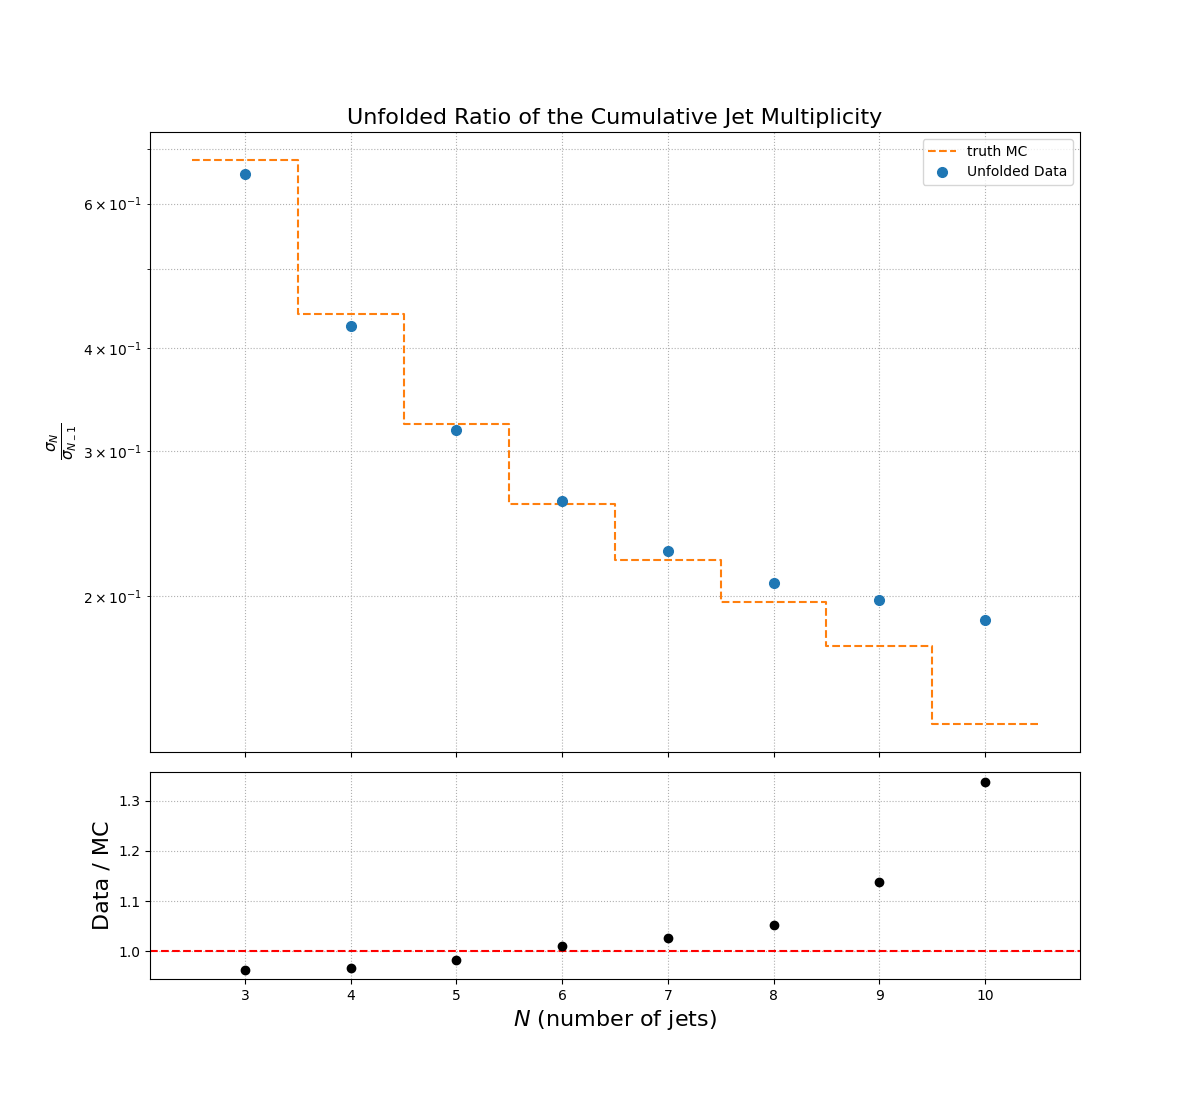

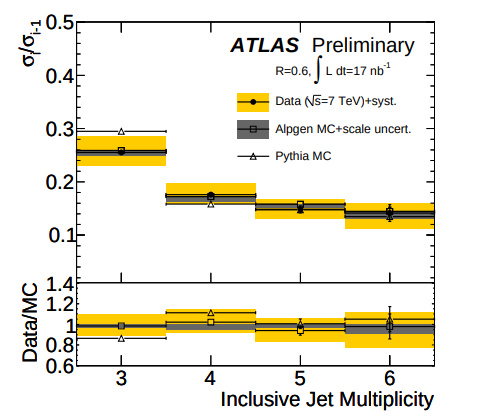



 Ratio of the n-jet cross section to the (n − 1)-jet cross section for n varying from 3 to 6 as
measured in data (solid circles) and as predicted by Alpgen+Herwig/Jimmy (open squares) and Pythia
(open triangles). The uncertainties in the jet energy scale and the unfolding of detector effects are shown
as a light orange band around the measurement. The range spanned by the Alpgen prediction when
varying the renormalization and factorization scales simultaneously is shown as a dark gray error band.
The bottom of the figure shows the ratio of data to Monte Carlo simulation (both for Alpgen and Pythia).
The scale uncertainty is shown as a dark gray band around one, and the measurement uncertainty is
shown around the points showing the ratio of data to Alpgen as a light orange band.